# GPU Acceleration

If you have an NVIDIA GPU, you can accelerate large and challenging optimization problems with the GPU. For this, install the RydOpt software with GPU support via `pip install rydopt[cuda12]` and set the JAX_PLATFORMS environment variable as follows:

In [1]:
# %pip install -q --progress-bar off rydopt[cuda12] # Uncomment for installation on Colab

import os

os.environ["JAX_PLATFORMS"] = "cuda,cpu"

Optionally, if you do not need double precision, you can set JAX_ENABLE_X64 to false for further accelerating the optimization. 

In [2]:
os.environ["JAX_ENABLE_X64"] = "false"

Afterwards, you can write your code as usual. To profit from the GPU acceleration, the optimization problem should be challenging enough. Thus, as an example problem, we search for a symmetric time-optimal pulse realizing a CCCZ gate.


Started optimization using 1 process



proc00:   0%|                                                                                                 …


=== Optimization finished using multi-start Adam ===

Duration: 247.088 seconds
Gates with infidelity below tol=1.0e-05: 51

Slowest gate:
> infidelity <= tol
> parameters = (16.854398727416992, [ 0.0510807  -0.28171003 -0.10378191 -0.57882023 -0.04444465 -0.36159739
  1.73398614 -1.59906983  1.51256466], [], [])
> duration = 16.854398727416992

Fastest gate:
> infidelity <= tol
> parameters = (12.405502319335938, [-0.93978846  0.73926961  1.39783883 -1.33574069  1.41905308 -2.03244734
  0.43103045 -0.73191214 -1.05958152], [], [])
> duration = 12.405502319335938
> one-sided bootstrap error on duration: 0.1


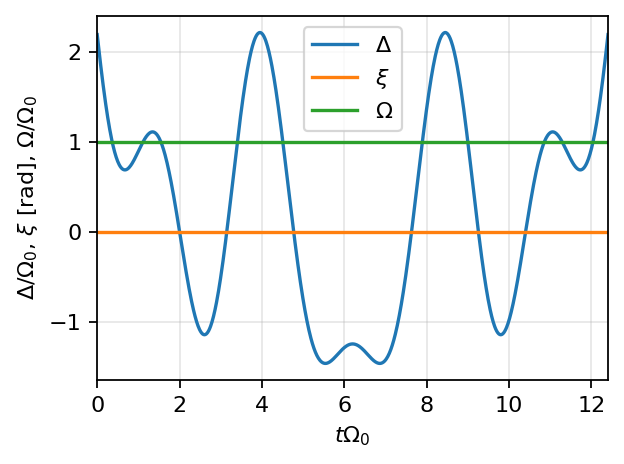

In [ ]:
import rydopt as ro
import numpy as np

# Want a CCCZ gate on four atoms in the perfect blockade regime; no Rydberg state decay
gate = ro.gates.FourQubitGatePyramidal(
    phi=None,
    theta=np.pi,
    theta_prime=np.pi,
    lamb=np.pi,
    lamb_prime=np.pi,
    kappa=np.pi,
    Vnn=float("inf"),
    Vnnn=float("inf"),
    decay=0.0,
)

# Pulse ansatz: constant offset plus cosine CRAB detuning ansatz
pulse_ansatz = ro.pulses.PulseAnsatz(detuning_ansatz=ro.pulses.ConstCosCrab(9))

# Initial pulse parameter guess:
# duration, detuning parameters, phase parameters, Rabi parameters
min_initial_params = ro.pulses.PulseParams(
    11.0,
    [-2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0, -2.0],
    [],
    [],
)
max_initial_params = ro.pulses.PulseParams(
    13.0,
    [2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0],
    [],
    [],
)

# Optimize the pulse parameters
opt_result = ro.optimization.multi_start_optimize(
    gate,
    pulse_ansatz,
    min_initial_params,
    max_initial_params,
    num_steps=1000,
    tol=1e-5,
    num_initializations=10000,
    min_converged_initializations=50,
)
optimized_params = opt_result.params

# Plot the pulse
ro.characterization.plot_pulse(pulse_ansatz, optimized_params);